# Check the demand

Accumulate the region of the user wishes.

Uses the `UserDispo` file.


The `UsersDispo` file has the same shape as the others, example:

```
6/8/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1784073600 0 0 0
N	YES:Faure
6/8/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1781395200 0 0 0
N	YES:Mattsn
6/22/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1782432000 0 0 0
N	NO:Ueda
6/30/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1782777600 0 0 0
N	NO:Ueda
7/1/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1783209600 0 0 0
N	NO:Ueda
7/20/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1785715200 0 0 0
N	YES:Radulescu
7/27/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1785715200 0 0 0
N	NO:Bove
7/27/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1785715200 0 0 0
N	NO:Tamtoegl
9/3/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1788998400 0 0 0
N	YES:Zhu
9/5/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1789257600 0 0 0
N	YES:Tamtoegl
9/7/2026  0:0:0  0:0:0  0:0:0  0:0:0  ---------- 0 0
R	86400 1789862400 0 0 0
```



In [531]:
%matplotlib widget
from datetime import datetime
import numpy as np
from matplotlib.pyplot import subplots

import pandas as pd
import sys
sys.path.append("/nethome/tofhr/ollivier/IN5/experiments_management/SoftTools/Gantt_Calendars/gantt-schedule/")
import src.libschedule as lg
from importlib import reload

In [141]:
reload(lg)

planfile = "/home/ollivier/Calendars/UsersDispo"  # <-- the usr dispo 

Experiments, Begin, End = lg.import_from_plan(planfile, PrintInfo=True)

Nb items in Exp:  557
Nb items in Date: 557
Nb items in Dur:  547


In [139]:
Experiments[:5], Begin[:5], End[:5]

(['NO:Brusselez',
  'NO:Judenstein/Zanotti',
  'NO:Brusselez',
  'NO:JOBIC',
  'NO:Brusselez'],
 ['11/1/2008', '11/1/2008', '11/17/2008', '12/5/2008', '12/8/2008'],
 [1226275200.0, 1228003200.0, 1228003200.0, 1229644800.0, 1229644800.0])

In [134]:
def user_wishes(Experiments, Begin, End):
    
    exp,dat,dur = [],[],[]
    for ex, Be, En in zip(Experiments, Begin, End):
        exp.append(ex)
        dat.append(datetime.strptime(Be, '%m/%d/%Y').strftime('%Y-%m-%d'))
        dur.append(datetime.strftime(datetime.fromtimestamp(int(En)), '%Y/%m/%d'))
        dur.append(datetime.fromtimestamp(int(En))  - datetime.strptime(Be, '%m/%d/%Y'))

    dct = {"Experiment": exp, "Begin": dat, "END": En, "Duration": dur}

    return pd.DataFrame(dct)

 

In [ ]:
df = user_wishes(Experiments, Begin, End)

df.head()

In [128]:
# datetime.fromtimestamp(int(End[-1])).date()
datetime.strftime(datetime.fromtimestamp(int(End[-1]))  , '%Y/%m/%d')


'2026/10/29'

In [ ]:
planfile = "/home/ollivier/serhome/IN5/experiments_management/SoftTools/Gantt_Calendars/gantt-schedule/tests/data/userDispo_test.txt"
planfile = "/home/ollivier/Calendars/UsersDispo"  # <-- the usr dispo 

In [546]:
from typing import List

def parse_carefully(filename:str, print_info: bool = True, verbose: bool = False) -> pd.DataFrame:
    
    # Read te file and store lines in a list
    with open(filename, 'r') as file: lines = file.readlines()
    lines = [line.strip() for line in lines if line.strip()]  # Remove empty lines
    
    experiments: List[str] = []
    dates: List[str] = []
    durations: List[float] = []

    idx = 0

    while True:

        line = lines[idx]

        if line[0].isdigit():
            a = " ".join(line.split()[0:1])
            idx += 1
        line = lines[idx]
        if not line.startswith("R"):
            idx += 1
            if verbose: print(f"Error in file: line No {idx}: {lines[idx]}")
            continue
        else:
            b = float(line.split()[2])
            idx += 1
        line = lines[idx]
        if line.startswith("N"):
            c = "-".join(line.split()[1:]).replace(",", "-").replace("_", "-")
            idx += 1

        dates.append(a)
        durations.append(b)
        experiments.append(c)
        if idx >= len(lines):
            break
  
    if print_info:
        print(f"Nb items in Exp:  {len(experiments)}")
        print(f"Nb items in Date: {len(dates)}")
        print(f"Nb items in Dur:  {len(durations)}")
    
    exp,dat,endd,dur = [],[],[],[]
    for ex, be, en in zip(experiments, dates, durations):
        exp.append(ex)
        # dat.append(datetime.strptime(be, '%m/%d/%Y').strftime('%Y-%m-%d'))
        # endd.append(datetime.strftime(datetime.fromtimestamp(int(en)), '%Y-%m-%d'))
        dat.append(datetime.strptime(be, '%m/%d/%Y'))
        endd.append(datetime.fromtimestamp(int(en)).date())

        dur.append((datetime.fromtimestamp(int(en))  - datetime.strptime(be, '%m/%d/%Y')).days)

    dct = {"Experiment": exp, "Start": dat, "Finish": endd, "Duration": dur}
    df = pd.DataFrame(dct)
    df['Bool'] = df.Experiment.map(lambda x: x.split(":")[0])
    df['Bool'] = df.Bool.map(lambda x: x.upper())
    df['User'] = df.Experiment.map(lambda x: x.split(":")[1] if len(x.split(":")) > 1 else "Unknown")
    df = df[['Experiment', 'User', 'Start', 'Finish', 'Duration', 'Bool']]


    return df



In [480]:
df = parse_carefully(planfile)
df.tail()

Nb items in Exp:  545
Nb items in Date: 545
Nb items in Dur:  545


,Experiment,User,Start,Finish,Duration,Bool
540,YES:Pan,Pan,2026-10-17,2026-10-23,6,YES
541,NO:Bove,Bove,2026-10-18,2026-10-29,11,NO
542,YES:Rodriguez,Rodriguez,2026-10-20,2026-10-29,9,YES
543,YES:Seels,Seels,2026-10-23,2026-10-29,6,YES
544,YES:Weber,Weber,2026-10-26,2026-10-29,3,YES


In [514]:
dflast = df[df['Start'] > datetime(2026,6,1)]

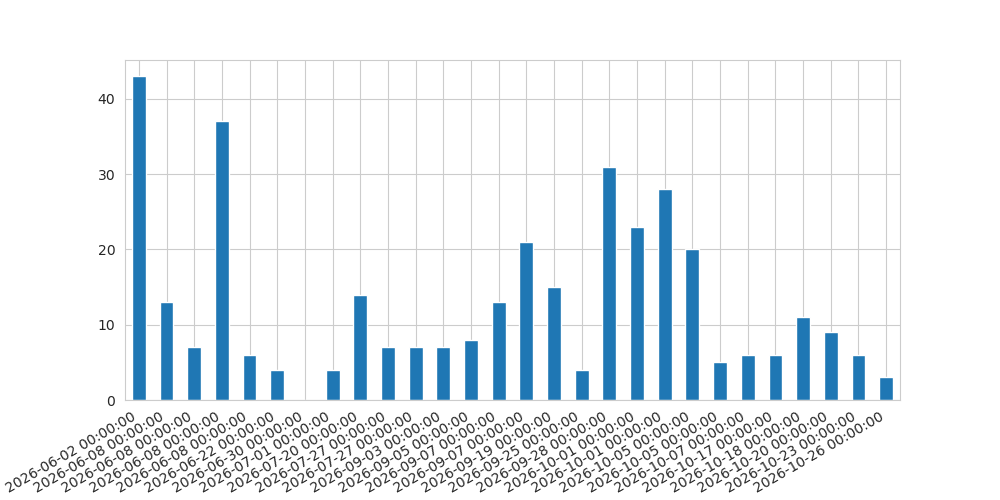

In [542]:
ax = dflast.plot(x='Start', y='Duration', kind='bar', figsize=(10, 5), legend=False)
ax.get_figure().autofmt_xdate()

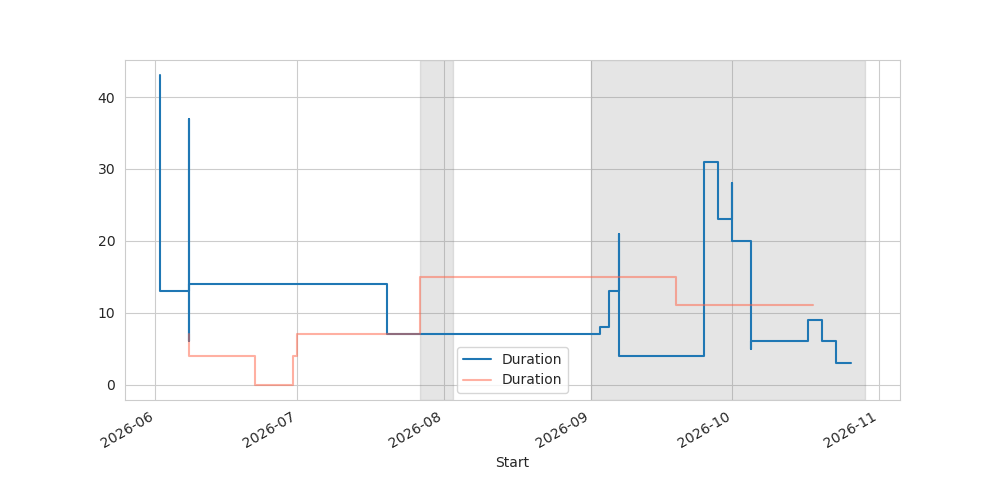

In [543]:

ax = dflast[dflast.Bool.str.contains('YES')].plot(x='Start', drawstyle='steps', y='Duration', figsize=(10, 5), legend=True)
dflast[dflast.Bool.str.contains('NO')].plot(x='Start', y= 'Duration', drawstyle='steps', figsize=(10, 5), ax=ax, color='tomato', alpha=0.5)
ax.axvspan(np.datetime64(datetime(2026,7,27)), np.datetime64(datetime(2026,8,3)), alpha=0.2, color='grey')
ax.axvspan(np.datetime64(datetime(2026,9,1)), np.datetime64(datetime(2026,10,29)), alpha=0.2, color='grey')
ax.get_figure().autofmt_xdate()

In [533]:
import seaborn as sns
sns.set_style("whitegrid")


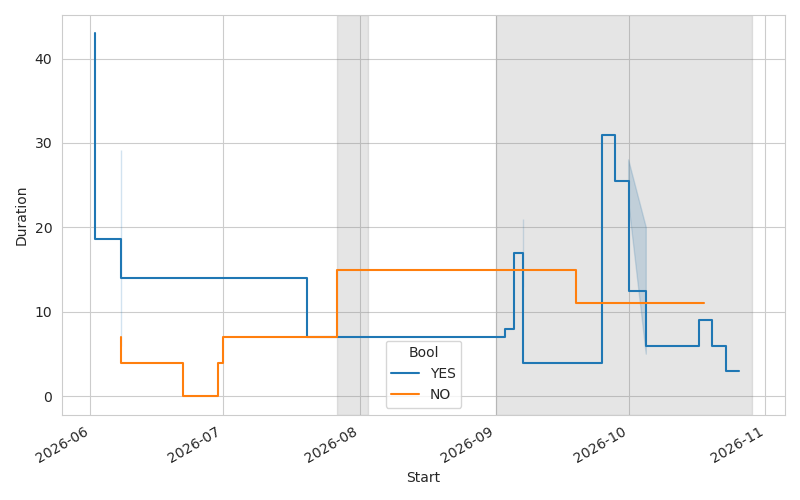

In [545]:
fig,ax = subplots(figsize=(8, 5))
sns.lineplot(x='Start',y='Duration', hue='Bool', data=dflast, drawstyle='steps-pre', ax=ax)
ax.axvspan(np.datetime64(datetime(2026,7,27)), np.datetime64(datetime(2026,8,3)), alpha=0.2, color='grey')
ax.axvspan(np.datetime64(datetime(2026,9,1)), np.datetime64(datetime(2026,10,29)), alpha=0.2, color='grey')

ax.get_figure().autofmt_xdate()
fig.tight_layout()

In [521]:
dflast.keys()

Index(['Experiment', 'User', 'Start', 'Finish', 'Duration', 'Bool'], dtype='object')